In [1]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation
from cycler import cycler

from IPython.display import HTML

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")




The basic [filter characteristics](https://ringbuffer.org/dsp/Digital_Filters/filter_characteristics/)
like low-pass, high-pass and band-pass have beein introduced earlier. 
In addition to these characteristics, different *filter designs* further specifiy the properties of the filter, respectively the transfer function. Across the literature, these approaches are also referred to as *types, topologies, ...*
Different designs have their benifits and drawbacks and may be preferred in specific applications.

There is a general trade-off between the strength of ripples in the pass-band or stop-band and the steepness of the slope.
The more effective a filter is, the more ripples it will introduce.
This is similar for the phase. A filter with a gentle **roll-off** (the slope between pass-band and stop-band) will have less undiserable effect on the phase of the signal.



The following filter types originally stem from the analog domain.
They are now commonly used to design digital filters.

------


# Butterworth

The Butterworth design is popular and frequently used for several reasons:

- flat frequency response in the passband (*maximally flat filter technique*)
- decent roll-off
- smooth phase response
- simple to design (using bilinear transformation or impulse invariance)


A Butterworth filter with the cutoff frequency $\omega_c$ nad filter order $N$ has the following transfer function,:

$$
|H(jΩ)| = \frac{1} {1 + \sqrt{( \omega / \omega_c)^{2N}}}
$$



## Roll-Off

Butterworth filters have linear slope in the passband when visualized in the Bode plot.
The steepness of the slope - the roll-off - depends on the order of the filter.
Per order it is $-6 \mathrm{dB}$ per octave, respectively $-20 \mathrm{dB}$ per decade, resulting in:

    - 1st order: -6dB
    - 2nd order: -12dB
    - 3rd order -18dB
    - ...




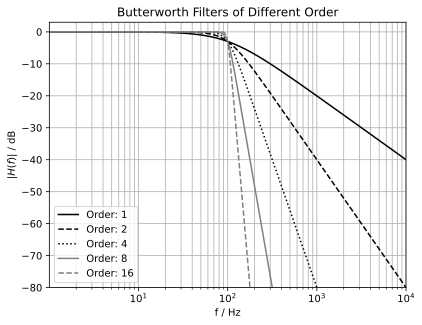

In [2]:
monochrome = (cycler('color', ['k','gray','gray']) * 
              cycler('linestyle', ['-', '--', ':']))
plt.rc('axes', prop_cycle= monochrome)

for N in [1,2,4,8,16]:

    b, a = signal.butter(N, 100, 'low', analog=True)
    w, h = signal.freqs(b, a,worN=np.linspace(0,10000,10000))
    plt.semilogx(w, 20 * np.log10(abs(h)), label="Order: "+str(N))

plt.ylim([-80,3])
plt.margins(0, 0.1)

plt.xlabel('f / Hz')
plt.ylabel('$|H(f)|$ / dB')
plt.grid(which='both', axis='both')
plt.legend()

plt.title('Butterworth Filters of Different Order')
plt.show()

-----

# Bessel

Bessel filters have one specific advantage over the other standard filters in this section:

- **maximum linear phase response** (maximum flat group delay)

This means they do not change the sinal's phase but only the amplitude spectrum.
As a downside, the Bessel filter is the **least effective filter type** per order.
The Bessel filter has been designed for use in a crossover.

The general transfer function of a Bessel filter is:

$$
H(s) = \frac{\theta_n(0)}{\theta_n \left( \frac{s}{\omega_0} \right)}
$$

With the reverse Bessel polynomials $\theta_n$:

$$
\theta_n(s) = \sum_{k=0}^n  \frac{(2n -k)!}{2^{n-k}k!(n-l)!}
$$

For a third order Bessel filter, this results in:

$$
{\displaystyle H(s) = \frac{15} {s^{3}+6s^{2}+15s+15}}
$$

-----

The plot below shows a Bessel low-pass filter with different orders:

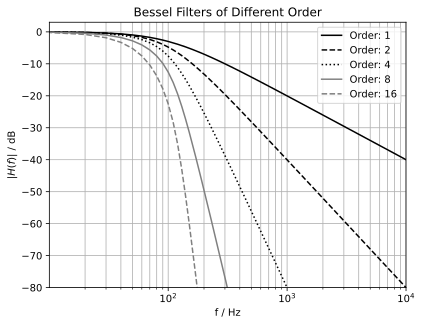

In [3]:
monochrome = (cycler('color', ['k','gray','gray']) * 
              cycler('linestyle', ['-', '--', ':']))
plt.rc('axes', prop_cycle= monochrome)

for N in [1,2,4,8,16]:
    
    b, a = signal.bessel(N, 100, 'low', analog=True, norm='phase')
    w, h = signal.freqs(b, a, worN=np.linspace(0,10000,1000))
    plt.semilogx(w, 20 * np.log10(np.abs(h)), label="Order: "+str(N))


plt.ylim([-80,3])
plt.margins(0, 0.1)

plt.xlabel('f / Hz')
plt.ylabel('$|H(f)|$ / dB')
plt.grid(which='both', axis='both')
plt.legend()

plt.title('Bessel Filters of Different Order')
plt.show()

-----

[\\]: https://web.ece.ucsb.edu/~yoga/courses/DSP/P17_Analog_Filters_P3.pdf

# Chebyshev

Chebyshev filters **can have a steeper slope** in the transition than the Butterworth design.

As a trade-off, this design shows ripples in the magnitude response:

- **Chebyshev Type I**: ripples in the pass-band
- **Chebyshev Type II**: ripples in the stop-band

----

The general transfer function of the Chebyshev Type I filter is:

$$
|H(j\omega)|^2 = \frac{1}{{1 + \varepsilon^2 C^2_N(\omega / \omega_0)}}
$$

$\varepsilon$ is the **ripple parameter**, $\omega_0$ the cutoff frequency and $C_N(\omega)$ a **Chebyshev polynomial** of the order $N$:

$$
C_N(\omega) = 
\begin{cases} 
\cos(N \cos^{-1} \omega), \ 0 \leq \omega \leq 1\\
\cosh(N \cosh^{-1} \omega), \ 0 \leq \omega \leq 1
\end{cases}
$$


The less common Chebyshev Type II filter (also inverse Chebyshev) has the following transfer function:

$$
|H(j\omega)|^2 = \frac{1}{{1 + \frac{1}{\varepsilon^2 C^2_N(\omega / \omega_0)}}}
$$

The following plots show Type I and Type II Chebyshev filters at different orders: 

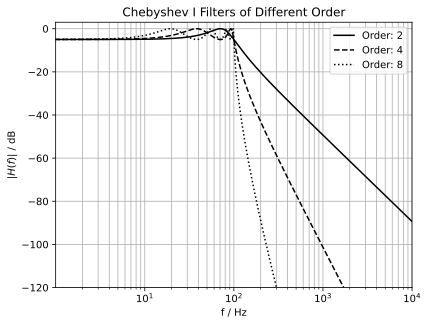

In [4]:
monochrome = (cycler('color', ['k','gray','gray']) * 
              cycler('linestyle', ['-', '--', ':']))
plt.rc('axes', prop_cycle= monochrome)

for N in [2,4,8]:

    b, a = signal.cheby1(N, 5, 100, 'low', analog=True)
    w, h = signal.freqs(b, a,worN=np.linspace(0,10000,10000))
    plt.semilogx(w, 20 * np.log10(abs(h)), label="Order: "+str(N))

plt.ylim([-120,3])
plt.margins(0, 0.1)

plt.xlabel('f / Hz')
plt.ylabel('$|H(f)|$ / dB')
plt.grid(which='both', axis='both')
plt.legend()

plt.title('Chebyshev I Filters of Different Order')
plt.show()


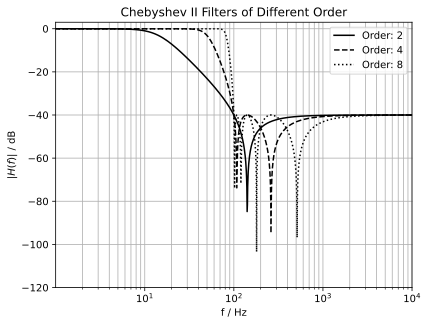

In [5]:
monochrome = (cycler('color', ['k','gray','gray']) * 
              cycler('linestyle', ['-', '--', ':']))
plt.rc('axes', prop_cycle= monochrome)

for N in [2,4,8]:

    b, a = signal.cheby2(N, 40, 100, 'low', analog=True)
    w, h = signal.freqs(b, a,worN=np.linspace(0,10000,10000))
    plt.semilogx(w, 20 * np.log10(abs(h)), label="Order: "+str(N))

plt.ylim([-120,3])
plt.margins(0, 0.1)

plt.xlabel('f / Hz')
plt.ylabel('$|H(f)|$ / dB')
plt.grid(which='both', axis='both')
plt.legend()

plt.title('Chebyshev II Filters of Different Order')
plt.show()


-----

# Elliptic (Cauer)

Elliptic filters have **ripples in both pass-band and stop-band**, leading to more distortions.
They also cause **significant phase distortions**. 

However, they can achieve the **sharpest cutoff** from the standard filter types introduced here.

When designing Elliptic filters, both the level of pass-band and stop-band ripples can be used as paramters.

$$
{H_n(\omega )={1 \over {\sqrt {1+\varepsilon ^{2}R_{n}^{2}(\xi ,\omega /\omega _{0})}}}}
$$

As for the Chebyshev I filter, $\varepsilon$ controls the ripples in the pass-band. 
The **selectivity factor** $\xi$ controls the stop-band ripples.
$R_{n}$ are Elliptic rational functions.

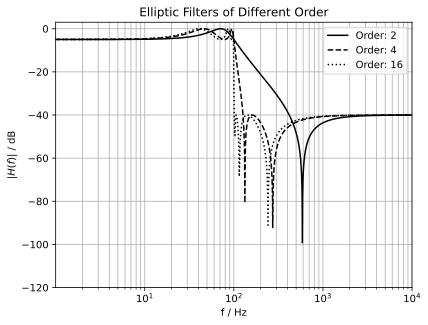

In [6]:
monochrome = (cycler('color', ['k','gray','gray']) * 
              cycler('linestyle', ['-', '--', ':']))
plt.rc('axes', prop_cycle= monochrome)

for N in [2,4,16]:

    b, a = signal.ellip(N, 5, 40, 100, 'low', analog=True)
    w, h = signal.freqs(b, a,worN=np.linspace(0,10000,10000))
    plt.semilogx(w, 20 * np.log10(abs(h)), label="Order: "+str(N))

plt.ylim([-120,3])
#plt.xlim([10e0,10e3])
plt.margins(0, 0.1)

plt.xlabel('f / Hz')
plt.ylabel('$|H(f)|$ / dB')
plt.grid(which='both', axis='both')
plt.legend()

plt.title('Elliptic Filters of Different Order')
plt.show();
